<a href="https://colab.research.google.com/github/Rocco6745667/2048/blob/main/NurealNetworkLab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

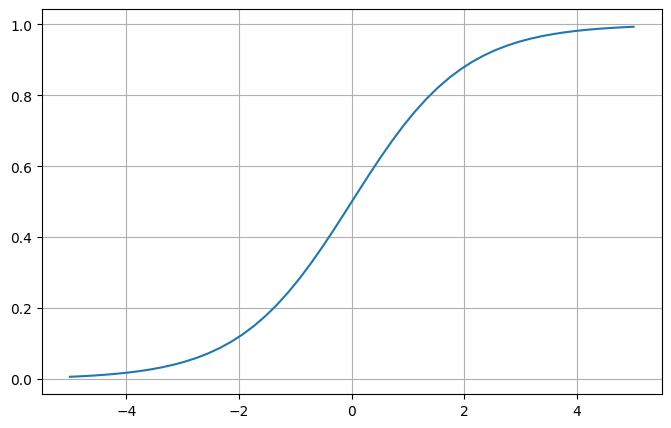

In [ ]:
#sigmoud function in python
x = np.linspace(-5, 5, 50)
z = 1/(1 + np.exp(-x))

plt.subplots(figsize=(8, 5))
plt.plot(x, z)
plt.grid()
plt.show()



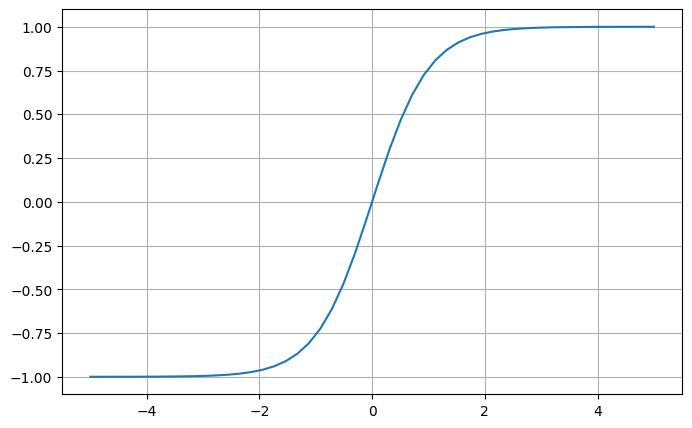

In [ ]:
#tanh function in python

x = np.linspace(-5, 5, 50)
z = (np.exp(x) - np.exp(-x))/(np.exp(x) + np.exp(-x))

plt.subplots(figsize=(8, 5))
plt.plot(x, z)
plt.grid()
plt.show()

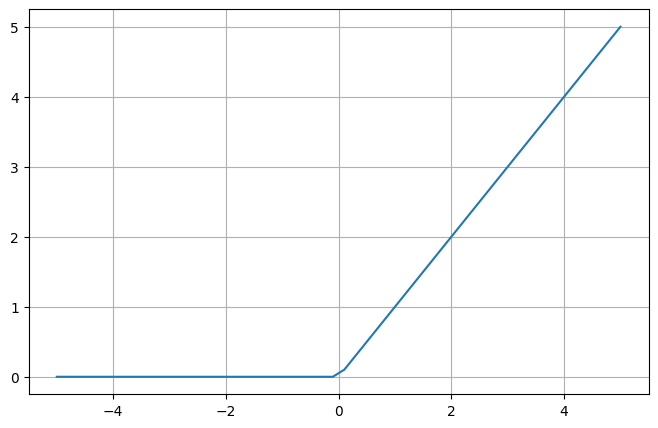

In [ ]:
#ReLu function in python

x = np.linspace(-5, 5, 50)
z = np.maximum(0, x)

plt.subplots(figsize=(8, 5))
plt.plot(x, z)
plt.grid()
plt.show()

In [ ]:
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split

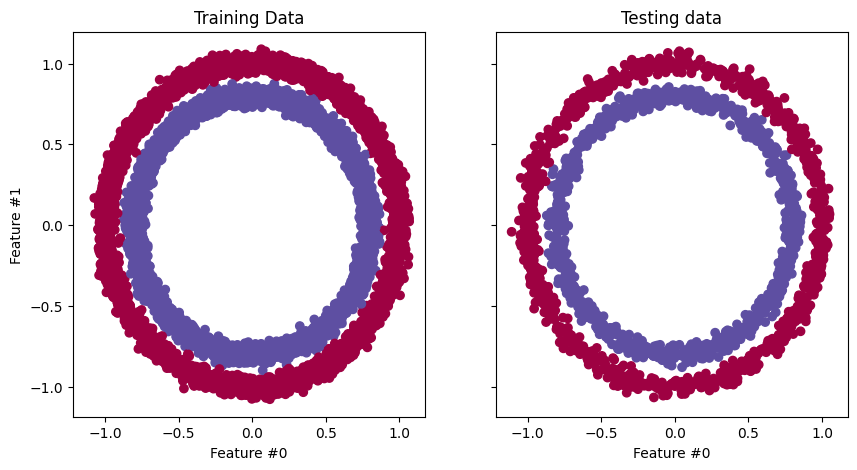

In [ ]:
#Create a dataset with 10,000 samples

n_samples = 10000
X, y = make_circles(n_samples=n_samples, noise=0.03, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Visualize the data

fig, (train_ax, test_ax) = plt.subplots(ncols= 2, sharex= True, sharey= True, figsize=(10, 5))
train_ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=plt.cm.Spectral)

train_ax.set_title("Training Data")
train_ax.set_xlabel("Feature #0")
train_ax.set_ylabel("Feature #1")

test_ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap=plt.cm.Spectral)
test_ax.set_xlabel("Feature #0")
test_ax.set_title("Testing data")
plt.show()

In [ ]:
import warnings
warnings.filterwarnings("ignore")

!pip install torch -q

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 58.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 48.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 29.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 49.2 MB/s eta 0:00:00


In [12]:
# Convert data to torch tensors
class Data(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X.astype(np.float32))
        self.y = torch.from_numpy(y.astype(np.float32))
        self.len = self.X.shape[0]

    def __getitem__(self, index):
        return self.X[index], self.y[index]

    def __len__(self):
        return self.len

In [13]:
batch_size = 64

In [14]:
# Instantiate training and test data
train_data = Data(X_train, y_train)
test_data = Data(X_test, y_test)

train_dataLoader = DataLoader(dataset=train_data, batch_size=batch_size, shuffle=True)
test_dataLoader = DataLoader(dataset=test_data, batch_size=batch_size, shuffle=False)

In [16]:
# Check it's working
for batch, (X, y) in enumerate(train_dataLoader):
    print(f"Batch: {batch+1}")
    print(f"X shape: {X.shape}")
    print(f"y shape: {y.shape}")
    break

Batch: 1
X shape: torch.Size([64, 2])
y shape: torch.Size([64])


In [17]:
from torch import optim

In [18]:
input_dim = 2
hidden_dim = 10
output_dim = 1

In [19]:
class NeuralNetwork(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(NeuralNetwork, self).__init__()
        self.layer_1 = nn.Linear(input_dim, hidden_dim)
        nn.init.kaiming_uniform_(self.layer_1.weight, nonlinearity="relu")
        self.layer_2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = torch.nn.functional.relu(self.layer_1(x))
        x = torch.nn.functional.sigmoid(self.layer_2(x))

        return x

model = NeuralNetwork(input_dim, hidden_dim, output_dim)
print(model)

NeuralNetwork(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=1, bias=True)
)


In [20]:
learning_rate = 0.1

In [21]:
loss_fn = nn.BCELoss()

In [22]:
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

In [23]:
#training the model
num_epochs = 100
loss_values = []

for epoch in range(num_epochs):
  for X, y in train_dataLoader:
    #zero the parameter graidants
    optimizer.zero_grad()

    #forward + backward + optimize
    pred = model(X)
    loss = loss_fn(pred, y.unsqueeze(-1))
    loss_values.append(loss.item())

    loss.backward()
    optimizer.step()

    print(f"Epoch: {epoch+1}/{num_epochs}, Loss: {loss.item():.4f}")
    print("training data complete")

  print(f"Epoch: {epoch+1}/{num_epochs}, Loss: {loss.item():.4f}")

Streaming output truncated to the last 5000 lines.
Epoch: 81/100, Loss: 0.0213
training data complete
Epoch: 81/100, Loss: 0.0284
training data complete
Epoch: 81/100, Loss: 0.0120
training data complete
Epoch: 81/100, Loss: 0.0225
training data complete
Epoch: 81/100, Loss: 0.0178
training data complete
Epoch: 81/100, Loss: 0.0119
training data complete
Epoch: 81/100, Loss: 0.0217
training data complete
Epoch: 81/100, Loss: 0.0093
training data complete
Epoch: 81/100, Loss: 0.0111
training data complete
Epoch: 81/100, Loss: 0.0179
training data complete
Epoch: 81/100, Loss: 0.0148
training data complete
Epoch: 81/100, Loss: 0.0173
training data complete
Epoch: 81/100, Loss: 0.0163
training data complete
Epoch: 81/100, Loss: 0.0153
training data complete
Epoch: 81/100, Loss: 0.0160
training data complete
Epoch: 81/100, Loss: 0.0112
training data complete
Epoch: 81/100, Loss: 0.0192
training data complete
Epoch: 81/100, Loss: 0.0169
training data complete
Epoch: 81/100, Loss: 0.0156
tra

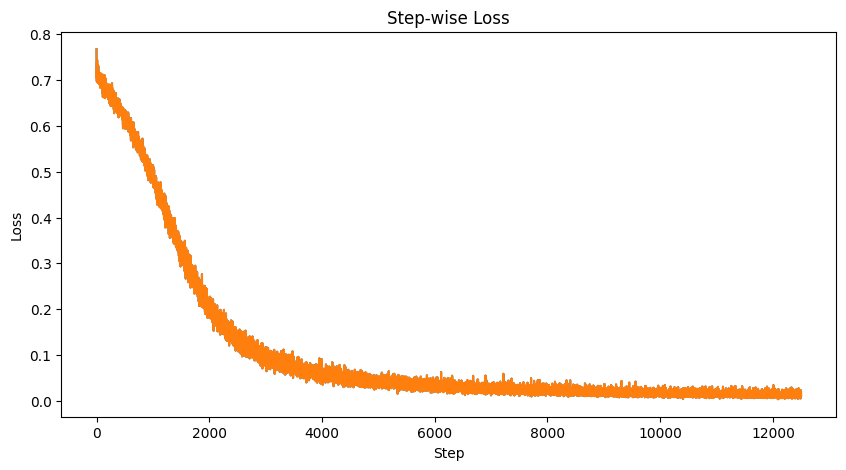

In [24]:
#Since we tracked the loss values, we can visualize the loss of the model over time.

step = range(len(loss_values))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(step, loss_values)
plt.plot(step, np.array(loss_values))
plt.title("Step-wise Loss")
ax.set_xlabel("Step")
ax.set_ylabel("Loss")

plt.show()

In [25]:
import itertools

In [26]:
# Initialize required variables
y_pred = []
y_test = []
correct = 0
total = 0

In [28]:
with torch.no_grad():
    for X, y in test_dataLoader:
        outputs = model(X)  # Get model outputs
        predicted = np.where(outputs.numpy() < 0.5, 0, 1)  # Convert to NumPy and apply threshold
        predicted = list(itertools.chain(*predicted))  # Flatten predictions
        y_pred.append(predicted)  # Append predictions
        y_test.append(y.numpy())  # Append true labels as NumPy
        total += y.size(0)  # Increment total count
        correct += (predicted == y.numpy()).sum().item()  # Count correct predictions

print(f'Accuracy of the network on the 3300 test instances: {100 * correct // total}%')

Accuracy of the network on the 3300 test instances: 100%


In [29]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import seaborn as sns

In [31]:
y_pred = list(itertools.chain(*y_pred))
y_test = list(itertools.chain(*y_test))

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      1013
         1.0       1.00      1.00      1.00       987

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



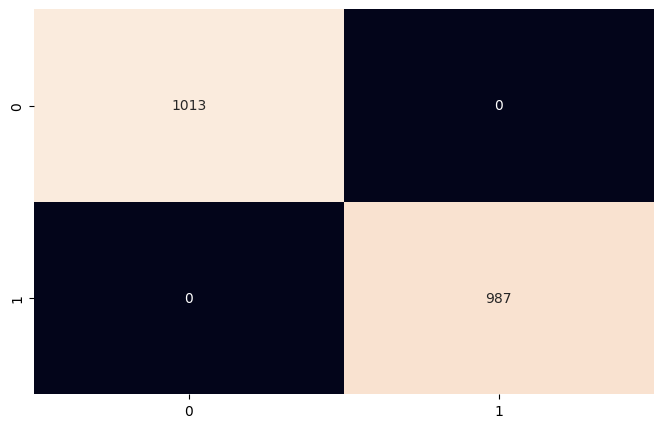

In [33]:
cf_matrix = confusion_matrix(y_test, y_pred)

plt.subplots(figsize=(8, 5))

sns.heatmap(cf_matrix, annot=True, cbar=False, fmt="g")

plt.show()